# Read LiveOcean Layers Icechunk Store

Opens the virtual Icechunk store created by `layers_icechunk.ipynb` in xarray.

In [1]:
import os
import icechunk
import xarray as xr

In [2]:
os.environ['AWS_REQUEST_CHECKSUM_CALCULATION'] = 'when_required'
os.environ['AWS_RESPONSE_CHECKSUM_VALIDATION'] = 'when_required'

In [3]:
storage_endpoint = "https://s3.kopah.uw.edu"
storage_bucket   = "liveocean-pmacc"
storage_name     = "icechunk-test-2"
bucket_url       = f"s3://{storage_bucket}"

In [4]:
storage = icechunk.s3_storage(
    bucket=storage_bucket,
    prefix=f"icechunk/{storage_name}",
    from_env=True,
    endpoint_url=storage_endpoint,
    region='not-used',
    force_path_style=True,
)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket_url}/",
        store=icechunk.s3_store(
            region="not-used",
            anonymous=False,
            s3_compatible=True,
            force_path_style=True,
            endpoint_url=storage_endpoint,
        ),
    )
)

credentials = icechunk.containers_credentials(
    {f"{bucket_url}/": icechunk.s3_credentials(anonymous=False)}
)

repo = icechunk.Repository.open(
    storage, config, authorize_virtual_chunk_access=credentials
)
session = repo.readonly_session("main")
print(repo)

<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: S3 (native)
    bucket: liveocean-pmacc
    prefix: icechunk/icechunk-test-2
    region: not-used
    endpoint_url: https://s3.kopah.uw.edu
    force_path_style: True
config: <RepositoryConfig ...>



In [5]:
ds = xr.open_zarr(session.store, consolidated=False, chunks={})
ds

IcechunkError:   x the checksum of the object owning the virtual chunk has changed (s3://liveocean-pmacc/LO_roms/cas7_t2_x11b/f2026.07.30/ocean_his_0002.nc)
  | 
  | context:
  |    0: icechunk::store::get
  |            with key="dstart/c" byte_range=From(0)
  |              at icechunk/src/store.rs:183
  | 
  `-> the checksum of the object owning the virtual chunk has changed (s3://liveocean-pmacc/LO_roms/cas7_t2_x11b/f2026.07.30/ocean_his_0002.nc)


In [6]:
ds.ocean_time.values

array(['2026-01-01T00:00:00.000000000', '2026-01-01T01:00:00.000000000',
       '2026-01-01T02:00:00.000000000', '2026-01-01T03:00:00.000000000',
       '2026-01-01T04:00:00.000000000', '2026-01-01T05:00:00.000000000',
       '2026-01-01T06:00:00.000000000', '2026-01-01T07:00:00.000000000',
       '2026-01-01T08:00:00.000000000', '2026-01-01T09:00:00.000000000',
       '2026-01-01T10:00:00.000000000', '2026-01-01T11:00:00.000000000',
       '2026-01-01T12:00:00.000000000', '2026-01-01T13:00:00.000000000',
       '2026-01-01T14:00:00.000000000', '2026-01-01T15:00:00.000000000',
       '2026-01-01T16:00:00.000000000', '2026-01-01T17:00:00.000000000',
       '2026-01-01T18:00:00.000000000', '2026-01-01T19:00:00.000000000',
       '2026-01-01T20:00:00.000000000', '2026-01-01T21:00:00.000000000',
       '2026-01-01T22:00:00.000000000', '2026-01-01T23:00:00.000000000',
       '2026-01-02T00:00:00.000000000', '2026-01-02T01:00:00.000000000',
       '2026-01-02T02:00:00.000000000', '2026-01-02

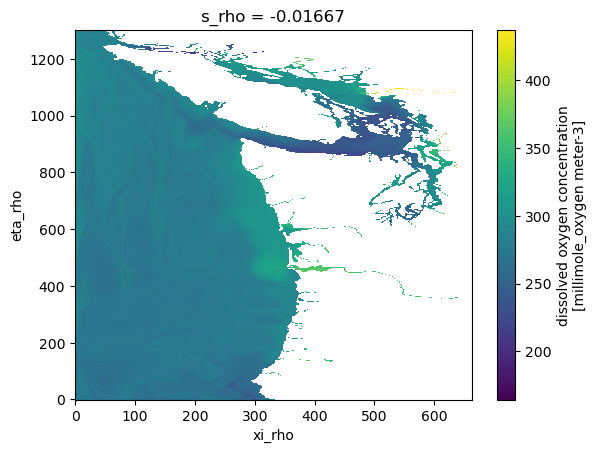

In [7]:
ds.oxygen[:,-1,:,:].mean(dim='ocean_time').plot()

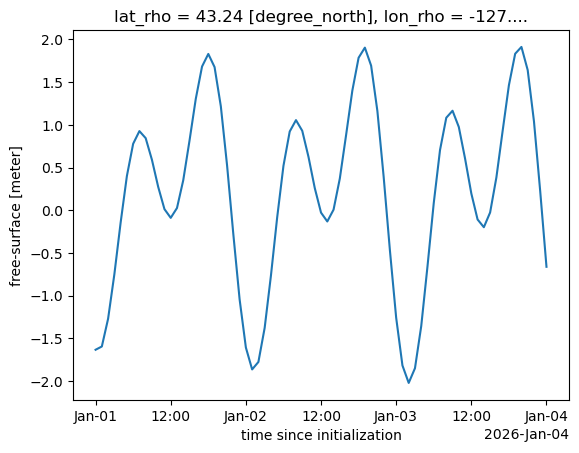

In [6]:
ds.zeta[:,100,100].plot()